# Latest H100 Optuna Search - FBNetGen PicSeq

This notebook performs a leak-free, resume-friendly Optuna hyperparameter search for `FBNetGenFromGraph` on PicSeq fold `.pkl` files, optimized for a single Colab H100.

The search objective is **validation subject-level Pearson r**. Test folds are only evaluated after Optuna chooses the best hyperparameters.

## What It Optimizes

- `lr`
- `weight_decay`
- `dropout`
- `hidden_dim`
- `n_layers`
- `n_heads`
- `batch_size`
- `refine_graph`
- `edge_temperature`
- `edge_mix_alpha`
- `edge_dropout`
- `sparsity_weight`
- `subject_loss_alpha`
- `corr_loss_beta`
- `subject_balanced_batches`

## H100 Speed Choices

- bf16 mixed precision
- TF32 enabled
- local scratch disk for fold files and outputs
- pinned-memory DataLoaders with worker prefetching
- Optuna pruning for bad trials
- train-fold cache in RAM
- sequential GPU trials by default, because one H100 usually trains fastest with one trial using the full GPU

## 1. Config

In [ ]:
# Drive inputs / outputs
DRIVE_FOLD_DIR     = '/content/drive/MyDrive/gnn-mri-picseq_v2'
DRIVE_OUTPUT_DIR   = '/content/drive/MyDrive/results/picseq_fbnetgen_h100_optuna_latest'

# Local scratch avoids slow Drive I/O during training.
USE_SCRATCH_DISK   = True
LOCAL_FOLD_DIR     = '/content/local-scratch/folds_picseq'
LOCAL_OUTPUT_DIR   = '/content/local-scratch/picseq_fbnetgen_h100_optuna_latest'
AVOID_OVERWRITE    = True
RESUME_FROM_DRIVE  = True   # keep Drive-backed Optuna/final checkpoints so Colab crashes can resume
CHECKPOINT_TO_DRIVE_EVERY_TRIAL = True

# Optuna search settings. TARGET_TOTAL_TRIALS is resume-friendly.
N_TRIALS           = 50
TARGET_TOTAL_TRIALS = N_TRIALS
OPTUNA_FOLD_LIMIT  = None       # use first 2 folds for fast search; set None for all folds
TRIAL_EPOCHS       = 40
TRIAL_PATIENCE     = 8

# Final training with the best config.
FINAL_EPOCHS       = 120
FINAL_PATIENCE     = 20

# H100 / high-RAM tuning
# RAM_SAFETY_MODE prevents CPU RAM blow-ups from fold caching + DataLoader worker copies.
RAM_SAFETY_MODE       = True
MAX_RAM_CACHE_FRACTION = 0.45
MAX_RAM_PERCENT_BEFORE_PRUNE = 90.0
DATALOADER_NUM_WORKERS = None  # auto: conservative for PyG object lists
VAL_TEST_NUM_WORKERS   = 0     # validation/test loaders stay in-process to avoid extra graph copies
DATALOADER_PREFETCH    = None  # auto: conservative prefetch
DATALOADER_PERSISTENT_WORKERS = False
BATCH_SIZE_CHOICES     = None  # auto: adapts to GPU VRAM
CACHE_FOLDS_IN_RAM     = None  # auto: cache folds when system RAM is sufficient
PRELOAD_NUM_WORKERS    = None  # auto: parallel CPU fold preload workers
FAST_H100_MODE         = True
USE_TORCH_COMPILE      = False  # PyG dynamic batches can compile slowly; enable only after a successful baseline

# Single-GPU Colab should keep this at 1. Use >1 only with real multi-GPU setup and separate devices.
OPTUNA_N_JOBS = 1

BASE_SEED = 42
NORMALIZE_METHOD = 'standard'
N_ROIS = 268

## 2. Setup Colab, GPU, and Dependencies

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os, sys, subprocess, shutil, json, math, time, random, gc
from concurrent.futures import ThreadPoolExecutor, as_completed
from pathlib import Path
from datetime import datetime

import torch

assert torch.cuda.is_available(), 'No GPU detected. In Colab: Runtime -> Change runtime type -> GPU.'
gpu_name = torch.cuda.get_device_name(0)
vram_gb = torch.cuda.get_device_properties(0).total_memory / 1e9
try:
    import psutil
    ram_gb = psutil.virtual_memory().total / 1e9
except Exception:
    psutil = None
    ram_gb = 0.0
print(f'GPU: {gpu_name} ({vram_gb:.1f} GB VRAM)')
print(f'System RAM: {ram_gb:.1f} GB' if ram_gb else 'System RAM: unknown')
if 'H100' not in gpu_name.upper():
    print('Warning: this notebook is tuned for H100, but it will still run on this GPU.')

torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True
torch.set_float32_matmul_precision('high')
torch.backends.cudnn.benchmark = FAST_H100_MODE
def adaptive_batch_sizes(vram_gb):
    if vram_gb >= 75:   # H100/A100 80GB class
        return [256, 512, 768, 1024]
    if vram_gb >= 45:   # A6000/A40/L40S class
        return [128, 256, 512, 768]
    if vram_gb >= 25:
        return [64, 128, 256, 512]
    return [32, 64, 128, 256]

def print_ram(label):
    if psutil is not None:
        vm = psutil.virtual_memory()
        print(f'{label} RAM used={vm.used/1e9:.1f} GB ({vm.percent:.1f}%), available={vm.available/1e9:.1f} GB')

cpu_count = os.cpu_count() or 2
if DATALOADER_NUM_WORKERS is None:
    # PyG keeps Python graph objects in each worker; too many workers can copy huge fold lists.
    if RAM_SAFETY_MODE:
        DATALOADER_NUM_WORKERS = 2 if ram_gb < 96 else 4
    else:
        DATALOADER_NUM_WORKERS = min(8, max(2, cpu_count // 2))
if DATALOADER_PREFETCH is None:
    DATALOADER_PREFETCH = 2 if RAM_SAFETY_MODE else (4 if ram_gb >= 80 else 2)
if BATCH_SIZE_CHOICES is None:
    BATCH_SIZE_CHOICES = adaptive_batch_sizes(vram_gb)
if CACHE_FOLDS_IN_RAM is None:
    CACHE_FOLDS_IN_RAM = False if RAM_SAFETY_MODE else ((ram_gb == 0.0) or (ram_gb >= 128))

print(f'RAM safety mode: {RAM_SAFETY_MODE}')
print(f'DataLoader workers: train={DATALOADER_NUM_WORKERS}, val/test={VAL_TEST_NUM_WORKERS}, prefetch={DATALOADER_PREFETCH}, persistent={DATALOADER_PERSISTENT_WORKERS}')
print(f'Batch-size search choices: {BATCH_SIZE_CHOICES}')
print(f'Cache folds in RAM: {CACHE_FOLDS_IN_RAM}')
print_ram('Initial')

AMP_DTYPE = torch.bfloat16 if torch.cuda.is_bf16_supported() else torch.float16
USE_BF16 = AMP_DTYPE == torch.bfloat16
print(f'AMP dtype: {AMP_DTYPE}')

GPU: NVIDIA RTX PRO 6000 Blackwell Server Edition (102.0 GB VRAM)
System RAM: 189.9 GB
RAM safety mode: True
DataLoader workers: train=4, val/test=0, prefetch=2, persistent=False
Batch-size search choices: [256, 512, 768, 1024]
Cache folds in RAM: False
Initial RAM used=2.1 GB (1.9%), available=186.3 GB
AMP dtype: torch.bfloat16


In [ ]:
# Install dependencies matched to the active Colab torch/CUDA build.
# If Colab already has them, pip will be quick.
torch_ver = torch.__version__.split('+')[0]
cuda_ver = 'cu' + torch.version.cuda.replace('.', '')
pyg_url = f'https://data.pyg.org/whl/torch-{torch_ver}+{cuda_ver}.html'
print(f'Installing PyG for torch={torch_ver}+{cuda_ver}')

subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'optuna', 'pandas', 'scikit-learn', 'scipy', 'openpyxl'])
subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'torch-geometric'])
subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'pyg-lib', 'torch-scatter', 'torch-sparse', 'torch-cluster', 'torch-spline-conv', '-f', pyg_url])

import optuna
print('Optuna:', optuna.__version__)

Installing PyG for torch=2.10.0+cu128
Optuna: 4.8.0


## 3. Prepare Folds and Output Folders

In [ ]:
def unique_dir(path: Path) -> Path:
    path = Path(path)
    if path.exists() and any(path.iterdir()) and AVOID_OVERWRITE:
        stamp = datetime.now().strftime('%Y%m%d_%H%M%S')
        path = path.with_name(f'{path.name}_{stamp}')
    path.mkdir(parents=True, exist_ok=True)
    return path

DRIVE_FOLD_PATH = Path(DRIVE_FOLD_DIR)
assert DRIVE_FOLD_PATH.exists(), f'Fold directory not found: {DRIVE_FOLD_PATH}'

drive_out = Path(DRIVE_OUTPUT_DIR) if RESUME_FROM_DRIVE else unique_dir(Path(DRIVE_OUTPUT_DIR))
drive_out.mkdir(parents=True, exist_ok=True)
if USE_SCRATCH_DISK:
    local_fold_path = Path(LOCAL_FOLD_DIR)
    local_fold_path.mkdir(parents=True, exist_ok=True)
    if not any(local_fold_path.glob('graphs_*.pkl')):
        fold_srcs = sorted(DRIVE_FOLD_PATH.glob('graphs_*.pkl'))
        copy_workers = min(8, max(1, len(fold_srcs)), max(2, (os.cpu_count() or 2) // 2))
        print(f'Copying {len(fold_srcs)} fold pkls to local scratch with {copy_workers} worker(s): {local_fold_path}')

        def copy_fold(fp):
            dst = local_fold_path / fp.name
            shutil.copy2(fp, dst)
            return fp.name, fp.stat().st_size / 1e6

        with ThreadPoolExecutor(max_workers=copy_workers) as ex:
            futures = [ex.submit(copy_fold, fp) for fp in fold_srcs]
            for fut in as_completed(futures):
                name, size_mb = fut.result()
                print(f'  {name} ({size_mb:.1f} MB)')
    else:
        print('Fold pkls already found on local scratch.')
    save_dir = Path(LOCAL_OUTPUT_DIR) if RESUME_FROM_DRIVE else unique_dir(Path(LOCAL_OUTPUT_DIR))
    save_dir.mkdir(parents=True, exist_ok=True)
else:
    local_fold_path = DRIVE_FOLD_PATH
    save_dir = drive_out

fold_files = sorted(local_fold_path.glob('graphs_*.pkl'))
assert fold_files, f'No graphs_*.pkl files found in {local_fold_path}'
total_fold_pkl_gb = sum(fp.stat().st_size for fp in fold_files) / 1e9
estimated_cache_gb = total_fold_pkl_gb * 3.0
if CACHE_FOLDS_IN_RAM and ram_gb and estimated_cache_gb > ram_gb * MAX_RAM_CACHE_FRACTION:
    print(f'Disabling fold RAM cache: estimated cache {estimated_cache_gb:.1f} GB exceeds {MAX_RAM_CACHE_FRACTION:.0%} of system RAM.')
    CACHE_FOLDS_IN_RAM = False
print(f'Found {len(fold_files)} fold(s), total pkl size={total_fold_pkl_gb:.1f} GB, estimated cache footprint={estimated_cache_gb:.1f} GB:')
for fp in fold_files:
    print(f'  {fp.name} ({fp.stat().st_size/1e9:.2f} GB)')
print(f'Working output: {save_dir}')
print(f'Final Drive output: {drive_out}')

def sync_file_to_drive(src, dst):
    src = Path(src); dst = Path(dst)
    if not RESUME_FROM_DRIVE or not src.exists() or src.resolve() == dst.resolve():
        return False
    dst.parent.mkdir(parents=True, exist_ok=True)
    shutil.copy2(src, dst)
    return True

def restore_file_from_drive(local_path, drive_path):
    local_path = Path(local_path); drive_path = Path(drive_path)
    if RESUME_FROM_DRIVE and drive_path.exists() and not local_path.exists():
        local_path.parent.mkdir(parents=True, exist_ok=True)
        shutil.copy2(drive_path, local_path)
        print(f'Restored checkpoint from Drive: {drive_path.name}')
        return True
    return False

def sync_tree_to_drive(src_dir, dst_dir):
    src_dir = Path(src_dir); dst_dir = Path(dst_dir)
    if not RESUME_FROM_DRIVE or not src_dir.exists() or src_dir.resolve() == dst_dir.resolve():
        return 0
    copied = 0
    for src in src_dir.rglob('*'):
        if src.is_file():
            dst = dst_dir / src.relative_to(src_dir)
            dst.parent.mkdir(parents=True, exist_ok=True)
            if not dst.exists() or dst.stat().st_size != src.stat().st_size:
                shutil.copy2(src, dst); copied += 1
    return copied

def restore_tree_from_drive(drive_dir, local_dir):
    drive_dir = Path(drive_dir); local_dir = Path(local_dir)
    if not RESUME_FROM_DRIVE or not drive_dir.exists() or drive_dir.resolve() == local_dir.resolve():
        return 0
    copied = 0
    for src in drive_dir.rglob('*'):
        if src.is_file():
            dst = local_dir / src.relative_to(drive_dir)
            dst.parent.mkdir(parents=True, exist_ok=True)
            if not dst.exists() or dst.stat().st_size != src.stat().st_size:
                shutil.copy2(src, dst); copied += 1
    if copied:
        print(f'Restored {copied} file(s) from Drive checkpoint: {drive_dir}')
    return copied

Copying 5 fold pkls to local scratch with 5 worker(s): /content/local-scratch/folds_picseq
  graphs_outer1_inner4.pkl (19005.0 MB)
  graphs_outer1_inner3.pkl (19005.0 MB)
  graphs_outer1_inner1.pkl (19005.0 MB)
  graphs_outer1_inner5.pkl (19005.0 MB)
  graphs_outer1_inner2.pkl (19005.0 MB)
Found 5 fold(s), total pkl size=95.0 GB, estimated cache footprint=285.1 GB:
  graphs_outer1_inner1.pkl (19.00 GB)
  graphs_outer1_inner2.pkl (19.00 GB)
  graphs_outer1_inner3.pkl (19.00 GB)
  graphs_outer1_inner4.pkl (19.00 GB)
  graphs_outer1_inner5.pkl (19.00 GB)
Working output: /content/local-scratch/picseq_fbnetgen_h100_optuna_latest
Final Drive output: /content/drive/MyDrive/results/picseq_fbnetgen_h100_optuna_latest


## 3.5. Sanity Check: Target Distribution + Simple Baselines

Before training a 200k-parameter GNN, check what the prediction problem actually looks like:

* **Target spread** — if the std of `PicSeq_Unadj` is small or the histogram is heavily piled up, there is just less signal to extract no matter the model.
* **Cheap baseline (mean predictor)** — predicting the *training mean* for every test subject. This is the floor; any real model has to beat this.
* **Linear baseline (Ridge on flattened LDW)** — fits a closed-form linear regression on the (268x268) connectivity matrix. If FBNetGen does not beat this, the GNN is not earning its complexity.

These numbers give the FBNetGen result the right context.

In [ ]:
import numpy as np
import pandas as pd
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from scipy.stats import pearsonr, spearmanr

import torch as _torch
from collections import defaultdict

print('=' * 70)
print('Target distribution per fold (PicSeq_Unadj)')
print('=' * 70)

def _per_subject_score_and_lt(graphs2d):
    """Average each subject's windows -> (n_subj, R*(R-1)/2) lower-triangle vector and y."""
    R = 268
    iu = np.triu_indices(R, k=1)
    rows_x, rows_y = [], []
    for subj_idx, row in enumerate(graphs2d):
        win_xs = []
        for g in row:
            if hasattr(g, 'pad') and bool(g.pad):
                continue
            x = g.x.float().cpu().numpy()
            win_xs.append(x[iu])
        if not win_xs:
            continue
        rows_x.append(np.mean(win_xs, axis=0))
        rows_y.append(float(row[0].y.item()))
    return np.array(rows_x), np.array(rows_y)

baseline_rows = []
for fp in fold_files:
    fold_name = fp.stem
    payload = _torch.load(fp, map_location='cpu', weights_only=False)
    train_x, train_y = _per_subject_score_and_lt(payload['train_graphs'])
    val_x,   val_y   = _per_subject_score_and_lt(payload['val_graphs'])
    test_x,  test_y  = _per_subject_score_and_lt(payload['test_graphs'])

    train_mean = train_y.mean()
    # Floor: predict mean
    mean_pred_test = np.full_like(test_y, train_mean)
    floor_mse = float(np.mean((mean_pred_test - test_y) ** 2))
    # Linear baseline: Ridge on flattened LDW
    sc = StandardScaler()
    train_x_s = sc.fit_transform(train_x)
    test_x_s  = sc.transform(test_x)
    ridge = Ridge(alpha=1.0).fit(train_x_s, train_y)
    ridge_pred = ridge.predict(test_x_s)
    if test_y.std() > 0 and ridge_pred.std() > 0:
        ridge_r = float(pearsonr(ridge_pred, test_y)[0])
        ridge_sr = float(spearmanr(ridge_pred, test_y)[0])
    else:
        ridge_r = ridge_sr = float('nan')
    ridge_mse = float(np.mean((ridge_pred - test_y) ** 2))

    baseline_rows.append({
        'fold': fold_name,
        'n_train_subj': len(train_y),
        'n_val_subj':   len(val_y),
        'n_test_subj':  len(test_y),
        'train_y_mean': float(train_y.mean()),
        'train_y_std':  float(train_y.std()),
        'test_y_mean':  float(test_y.mean()),
        'test_y_std':   float(test_y.std()),
        'mean_pred_test_mse':  floor_mse,
        'ridge_test_pearson_r':  ridge_r,
        'ridge_test_spearman_r': ridge_sr,
        'ridge_test_mse':  ridge_mse,
    })
    print(f'  {fold_name}: '
          f'n=(tr {len(train_y)}, va {len(val_y)}, te {len(test_y)}), '
          f'train_y mean={train_y.mean():+.2f} std={train_y.std():.2f}, '
          f'Ridge test r={ridge_r:+.3f}, MSE={ridge_mse:.3f}')
    del payload, train_x, train_y, val_x, val_y, test_x, test_y, train_x_s, test_x_s, ridge, ridge_pred, mean_pred_test
    gc.collect()

baseline_df = pd.DataFrame(baseline_rows)
baseline_csv = save_dir / 'baselines_per_fold.csv'
baseline_df.to_csv(baseline_csv, index=False)
print()
print(f'Mean Ridge test r across folds: {baseline_df["ridge_test_pearson_r"].mean():+.4f} +/- {baseline_df["ridge_test_pearson_r"].std():.4f}')
print(f'(FBNetGen has to beat this to justify the GNN.)')
print(f'Saved baselines to: {baseline_csv}')

# Histogram of all subject-level y values
try:
    import matplotlib.pyplot as plt
    all_y = np.concatenate([_torch.load(fp, map_location='cpu', weights_only=False) and []  # noop to satisfy linter
                             for fp in []])  # not used
    # Just use training y from fold 0
    payload0 = _torch.load(fold_files[0], map_location='cpu', weights_only=False)
    _, train_y0 = _per_subject_score_and_lt(payload0['train_graphs'])
    _, val_y0   = _per_subject_score_and_lt(payload0['val_graphs'])
    _, test_y0  = _per_subject_score_and_lt(payload0['test_graphs'])
    all_y = np.concatenate([train_y0, val_y0, test_y0])
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.hist(all_y, bins=30, color='steelblue', edgecolor='black')
    ax.set_xlabel('PicSeq_Unadj'); ax.set_ylabel('subjects')
    ax.set_title(f'Score distribution (fold 1)  n={len(all_y)}, mean={all_y.mean():.2f}, std={all_y.std():.2f}')
    plt.tight_layout()
    plt.savefig(save_dir / 'target_distribution.png', dpi=150)
    plt.show()
    plt.close()
    del payload0, train_y0, val_y0, test_y0, all_y
    gc.collect()
except Exception as e:
    print(f'Could not plot histogram: {e}')

del _torch  # avoid shadowing


Target distribution per fold (PicSeq_Unadj)
  graphs_outer1_inner1: n=(tr 116, va 30, te 37), train_y mean=+113.10 std=12.97, Ridge test r=+0.314, MSE=200.418
  graphs_outer1_inner2: n=(tr 117, va 29, te 37), train_y mean=+113.81 std=13.85, Ridge test r=+0.136, MSE=235.445
  graphs_outer1_inner3: n=(tr 117, va 29, te 37), train_y mean=+112.41 std=13.78, Ridge test r=+0.210, MSE=219.578
  graphs_outer1_inner4: n=(tr 117, va 29, te 37), train_y mean=+112.93 std=13.18, Ridge test r=+0.169, MSE=219.569
  graphs_outer1_inner5: n=(tr 117, va 29, te 37), train_y mean=+111.75 std=14.06, Ridge test r=+0.112, MSE=236.920

Mean Ridge test r across folds: +0.1882 +/- 0.0792
(FBNetGen has to beat this to justify the GNN.)
Saved baselines to: /content/local-scratch/picseq_fbnetgen_h100_optuna_latest/baselines_per_fold.csv
Could not plot histogram: need at least one array to concatenate


## 4. Model, Data Utilities, and Metrics

In [ ]:
import math
import random
import numpy as np
import pandas as pd
import torch.nn as nn
import torch.nn.functional as F
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy.stats import pearsonr, spearmanr
from torch_geometric.nn import GATv2Conv, global_mean_pool, global_add_pool
from torch_geometric.utils import softmax as pyg_softmax
from torch_geometric.loader import DataLoader

class GNNPredictor(nn.Module):
    def __init__(self, in_dim=128, hidden_dim=128, out_dim=1, n_layers=3, heads=2, dropout=0.25):
        super().__init__()
        assert hidden_dim % heads == 0, 'hidden_dim must be divisible by n_heads'
        self.input_proj = nn.Linear(in_dim, hidden_dim)
        self.gat_layers = nn.ModuleList()
        self.norms = nn.ModuleList()
        for _ in range(n_layers):
            self.gat_layers.append(GATv2Conv(
                hidden_dim, hidden_dim // heads, heads=heads,
                dropout=dropout, concat=True, edge_dim=1,
            ))
            self.norms.append(nn.LayerNorm(hidden_dim))
        self.pool_gate = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim), nn.Tanh(), nn.Linear(hidden_dim, 1),
        )
        self.mlp = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim // 2), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, out_dim),
        )

    def forward(self, node_features, edge_index, edge_weight, batch):
        x = self.input_proj(node_features)
        edge_attr = edge_weight.unsqueeze(-1) if edge_weight is not None and edge_weight.dim() == 1 else edge_weight
        for i, (gat, norm) in enumerate(zip(self.gat_layers, self.norms)):
            x_res = x
            x = gat(x, edge_index, edge_attr=edge_attr)
            x = norm(F.elu(x))
            if i > 0:
                x = x + x_res
        # Keep pooling in fp32 for stable correlations/metrics.
        with torch.amp.autocast('cuda', enabled=False):
            x = x.float()
            x_mean = global_mean_pool(x, batch)
            gate = self.pool_gate(x).squeeze(-1)
            weights = pyg_softmax(gate, batch).unsqueeze(-1)
            x_attn = global_add_pool(x * weights, batch)
            out = self.mlp(torch.cat([x_mean, x_attn], dim=-1))
        return out.squeeze(-1)

class FBNetGenFromGraph(nn.Module):
    def __init__(
        self,
        in_dim=268,
        hidden_dim=128,
        n_layers=3,
        n_heads=2,
        dropout=0.25,
        refine_graph=True,
        edge_temperature=1.0,
        edge_mix_alpha=0.25,
        edge_dropout=0.0,
    ):
        super().__init__()
        self.refine_graph = refine_graph
        self.edge_temperature = float(edge_temperature)
        self.edge_mix_alpha = float(edge_mix_alpha)
        self.edge_dropout_p = float(edge_dropout)
        self.node_encoder = nn.Sequential(
            nn.Linear(in_dim, hidden_dim), nn.LayerNorm(hidden_dim), nn.ReLU(), nn.Dropout(dropout),
        )
        if refine_graph:
            self.W_q = nn.Linear(hidden_dim, hidden_dim // 2)
            self.W_k = nn.Linear(hidden_dim, hidden_dim // 2)
            self.edge_scorer = nn.Linear(hidden_dim // 2, 1)
        self.predictor = GNNPredictor(
            in_dim=hidden_dim, hidden_dim=hidden_dim,
            n_layers=n_layers, heads=n_heads, dropout=dropout,
        )

    def forward(self, data, return_aux=False):
        x, edge_index, batch = data.x, data.edge_index, data.batch
        edge_attr = data.edge_attr if hasattr(data, 'edge_attr') else None
        x = self.node_encoder(x)
        aux = {}
        if self.refine_graph and edge_index.size(1) > 0:
            src, dst = edge_index[0], edge_index[1]
            q = self.W_q(x[src])
            k = self.W_k(x[dst])
            raw_score = self.edge_scorer(q * k) / max(self.edge_temperature, 1e-3)
            attn_score = torch.sigmoid(raw_score)

            if self.training and self.edge_dropout_p > 0:
                keep = (torch.rand_like(attn_score) >= self.edge_dropout_p).to(attn_score.dtype)
                attn_score = attn_score * keep
            ea = edge_attr if (edge_attr is None or edge_attr.dim() == 2) else edge_attr.unsqueeze(-1)
            if ea is not None:
                # Residual edge mixing keeps the LDW prior while learning task-aware refinement.
                refined = ea * attn_score
                edge_weight = self.edge_mix_alpha * ea + (1.0 - self.edge_mix_alpha) * refined
            else:
                edge_weight = attn_score
            aux['edge_sparsity'] = edge_weight.abs().mean()
            aux['edge_attention_mean'] = attn_score.mean().detach()
        else:
            edge_weight = edge_attr
            if edge_weight is not None:
                aux['edge_sparsity'] = edge_weight.abs().mean()
        out = self.predictor(x, edge_index, edge_weight, batch)
        if return_aux:
            return out, aux
        return out


def normalize_targets(scores, method='standard', scaler=None, fit=True):
    arr = np.asarray(scores, dtype=float).reshape(-1, 1)
    if scaler is None:
        if method == 'standard': scaler = StandardScaler()
        elif method == 'minmax': scaler = MinMaxScaler(feature_range=(-1, 1))
        elif method == 'robust': scaler = RobustScaler()
        else: raise ValueError(f'Unknown normalize method: {method}')
    out = scaler.fit_transform(arr) if fit else scaler.transform(arr)
    return out.flatten(), scaler


def flatten_graph_array(arr2d):
    flat, targets, sids = [], [], []
    for subj_idx, row in enumerate(arr2d):
        for g in row:
            if hasattr(g, 'pad') and bool(g.pad):
                continue
            g.subject_id = torch.tensor([subj_idx], dtype=torch.long)
            flat.append(g)
            targets.append(float(g.y.item()))
            sids.append(subj_idx)
    return flat, np.asarray(targets), np.asarray(sids)

FOLD_CACHE = {}

def load_graphs_with_normalization(fold_path, normalize_method='standard'):
    fold_path = str(fold_path)
    cache_key = (fold_path, normalize_method)
    if CACHE_FOLDS_IN_RAM and cache_key in FOLD_CACHE:
        return FOLD_CACHE[cache_key]
    print(f'Loading fold: {Path(fold_path).name}')
    graphs = torch.load(fold_path, map_location='cpu', weights_only=False)
    train_list, train_t, train_sids = flatten_graph_array(graphs['train_graphs'])
    val_list, val_t, val_sids = flatten_graph_array(graphs['val_graphs'])
    test_list, test_t, test_sids = flatten_graph_array(graphs['test_graphs'])
    train_n, scaler = normalize_targets(train_t, method=normalize_method, fit=True)
    val_n, _ = normalize_targets(val_t, method=normalize_method, scaler=scaler, fit=False)
    test_n, _ = normalize_targets(test_t, method=normalize_method, scaler=scaler, fit=False)
    for i, g in enumerate(train_list): g.y = torch.tensor(train_n[i], dtype=torch.float32)
    for i, g in enumerate(val_list): g.y = torch.tensor(val_n[i], dtype=torch.float32)
    for i, g in enumerate(test_list): g.y = torch.tensor(test_n[i], dtype=torch.float32)
    payload = (train_list, val_list, test_list, {
        'scaler': scaler,
        'train_subject_ids': train_sids,
        'val_subject_ids': val_sids,
        'test_subject_ids': test_sids,
    })
    if CACHE_FOLDS_IN_RAM:
        FOLD_CACHE[cache_key] = payload
    del graphs
    gc.collect()
    print(f'  windows train={len(train_list)} val={len(val_list)} test={len(test_list)}')
    return payload


class SubjectBatchSampler:
    def __init__(self, graphs, max_graphs_per_batch=256, shuffle=True, seed=42):
        self.graphs = graphs
        self.max_graphs_per_batch = int(max_graphs_per_batch)
        self.shuffle = shuffle
        self.seed = seed
        self.epoch = 0
        groups = {}
        for idx, g in enumerate(graphs):
            sid = int(g.subject_id.view(-1)[0].item()) if hasattr(g, 'subject_id') else idx
            groups.setdefault(sid, []).append(idx)
        self.groups = groups
        self.subject_ids = list(groups.keys())

    def __iter__(self):
        rng = random.Random(self.seed + self.epoch)
        self.epoch += 1
        subject_ids = self.subject_ids.copy()
        if self.shuffle:
            rng.shuffle(subject_ids)
        batch = []
        for sid in subject_ids:
            idxs = self.groups[sid].copy()
            if self.shuffle:
                rng.shuffle(idxs)
            if batch and len(batch) + len(idxs) > self.max_graphs_per_batch:
                yield batch
                batch = []
            if len(idxs) > self.max_graphs_per_batch:
                for start in range(0, len(idxs), self.max_graphs_per_batch):
                    chunk = idxs[start:start + self.max_graphs_per_batch]
                    if chunk:
                        yield chunk
            else:
                batch.extend(idxs)
        if batch:
            yield batch

    def __len__(self):
        n_batches, n = 0, 0
        for sid in self.subject_ids:
            group_len = len(self.groups[sid])
            if n and n + group_len > self.max_graphs_per_batch:
                n_batches += 1
                n = 0
            if group_len > self.max_graphs_per_batch:
                n_batches += int(math.ceil(group_len / self.max_graphs_per_batch))
            else:
                n += group_len
        return n_batches + int(n > 0)


def _loader_kwargs(num_workers, prefetch_factor):
    num_workers = int(max(0, num_workers))
    kwargs = {'num_workers': num_workers, 'pin_memory': True}
    if num_workers > 0:
        kwargs['prefetch_factor'] = int(max(1, prefetch_factor))
        kwargs['persistent_workers'] = bool(DATALOADER_PERSISTENT_WORKERS)
    return kwargs


def create_dataloaders(train_g, val_g, test_g, batch_size=256, num_workers=2, prefetch_factor=2, subject_balanced=True, seed=42, include_test=True):
    train_kwargs = _loader_kwargs(num_workers, prefetch_factor)
    eval_kwargs = _loader_kwargs(VAL_TEST_NUM_WORKERS, 1)
    if subject_balanced:
        train_sampler = SubjectBatchSampler(train_g, max_graphs_per_batch=batch_size, shuffle=True, seed=seed)
        train_loader = DataLoader(train_g, batch_sampler=train_sampler, **train_kwargs)
    else:
        train_loader = DataLoader(train_g, batch_size=batch_size, shuffle=True, **train_kwargs)
    return (
        train_loader,
        DataLoader(val_g, batch_size=batch_size, shuffle=False, **eval_kwargs),
        DataLoader(test_g, batch_size=batch_size, shuffle=False, **eval_kwargs) if include_test else None,
    )


def preload_folds_parallel(fold_paths, normalize_method='standard'):
    fold_paths = list(fold_paths)
    if not fold_paths:
        return
    workers = PRELOAD_NUM_WORKERS or (1 if RAM_SAFETY_MODE else min(4, len(fold_paths), max(1, DATALOADER_NUM_WORKERS // 2)))
    if workers <= 1:
        for fp in fold_paths:
            load_graphs_with_normalization(fp, normalize_method)
        return
    print(f'Preloading {len(fold_paths)} fold(s) into RAM with {workers} worker(s)...')
    with ThreadPoolExecutor(max_workers=workers) as ex:
        futures = [ex.submit(load_graphs_with_normalization, fp, normalize_method) for fp in fold_paths]
        for fut in as_completed(futures):
            fut.result()


def safe_corr(preds, targets):
    if len(preds) < 2 or np.std(preds) == 0 or np.std(targets) == 0:
        return float('nan')
    return float(pearsonr(preds, targets)[0])


def safe_spearman(preds, targets):
    if len(preds) < 2 or np.std(preds) == 0 or np.std(targets) == 0:
        return float('nan')
    return float(spearmanr(preds, targets)[0])


def compute_metrics(preds, targets):
    preds = np.asarray(preds, dtype=float)
    targets = np.asarray(targets, dtype=float)
    return {
        'mse': float(mean_squared_error(targets, preds)),
        'mae': float(mean_absolute_error(targets, preds)),
        'r': safe_corr(preds, targets),
        'spearman_r': safe_spearman(preds, targets),
        'r2': float(r2_score(targets, preds)) if len(preds) >= 2 else float('nan'),
    }


def aggregate_window_predictions(preds, targets, sids):
    sids = np.asarray(sids).flatten()
    uniq = np.unique(sids)
    subj_preds = np.asarray([preds[sids == sid].mean() for sid in uniq])
    subj_targets = np.asarray([targets[sids == sid].mean() for sid in uniq])
    return subj_preds, subj_targets, uniq


def subject_predictions_from_graphs(preds, targets, graphs):
    # Evaluation loaders use shuffle=False, so graph order matches prediction order.
    sids = np.asarray([int(g.subject_id.view(-1)[0].item()) for g in graphs])
    subj_preds, subj_targets, subj_ids = aggregate_window_predictions(preds, targets, sids)
    return {
        'subject_id': subj_ids.astype(int).tolist(),
        'pred': subj_preds.astype(float).tolist(),
        'target': subj_targets.astype(float).tolist(),
    }

print('Model and data utilities ready.')

Model and data utilities ready.


## 5. Training Helpers

In [ ]:
device = torch.device('cuda')

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = not FAST_H100_MODE
    torch.backends.cudnn.benchmark = FAST_H100_MODE


def with_config_defaults(config):
    out = dict(config)
    defaults = {
        'edge_temperature': 1.0,
        'edge_mix_alpha': 0.25,
        'edge_dropout': 0.0,
        'sparsity_weight': 0.0,
        'subject_loss_alpha': 0.5,
        'corr_loss_beta': 0.1,
        'subject_balanced_batches': True,
    }
    for k, v in defaults.items():
        out.setdefault(k, v)
    return out


def build_model(config, in_dim):
    config = with_config_defaults(config)
    model = FBNetGenFromGraph(
        in_dim=in_dim,
        hidden_dim=config['hidden_dim'],
        n_layers=config['n_layers'],
        n_heads=config['n_heads'],
        dropout=config['dropout'],
        refine_graph=config['refine_graph'],
        edge_temperature=config['edge_temperature'],
        edge_mix_alpha=config['edge_mix_alpha'],
        edge_dropout=config['edge_dropout'],
    ).to(device)
    if USE_TORCH_COMPILE:
        model = torch.compile(model, mode='reduce-overhead')
    return model


def build_scheduler(optimizer, epochs, lr):
    warmup = max(1, epochs // 5)
    return torch.optim.lr_scheduler.SequentialLR(
        optimizer,
        schedulers=[
            torch.optim.lr_scheduler.LinearLR(optimizer, start_factor=0.1, end_factor=1.0, total_iters=warmup),
            torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max(1, epochs - warmup), eta_min=lr * 0.01),
        ],
        milestones=[warmup],
    )


def batch_subject_means(values, targets, subject_ids):
    subject_ids = subject_ids.view(-1).long()
    unique_ids, inverse = torch.unique(subject_ids, sorted=False, return_inverse=True)
    n_subjects = unique_ids.numel()
    sums = torch.zeros(n_subjects, device=values.device, dtype=values.float().dtype)
    target_sums = torch.zeros_like(sums)
    counts = torch.zeros(n_subjects, device=values.device, dtype=values.float().dtype)
    sums.scatter_add_(0, inverse, values.float())
    target_sums.scatter_add_(0, inverse, targets.float())
    counts.scatter_add_(0, inverse, torch.ones_like(values.float()))
    return sums / counts.clamp_min(1.0), target_sums / counts.clamp_min(1.0)


def pearson_corr_loss(preds, targets):
    preds = preds.float()
    targets = targets.float()
    if preds.numel() < 2:
        return preds.new_tensor(0.0)
    pred_centered = preds - preds.mean()
    target_centered = targets - targets.mean()
    denom = (pred_centered.norm() * target_centered.norm()).clamp_min(1e-8)
    corr = (pred_centered * target_centered).sum() / denom
    return 1.0 - corr.clamp(-1.0, 1.0)


def training_loss(preds, targets, subject_ids, aux, config, criterion):
    config = with_config_defaults(config)
    window_loss = criterion(preds, targets.float())
    total = window_loss
    parts = {'window_mse': window_loss.detach()}
    if subject_ids is not None:
        subj_preds, subj_targets = batch_subject_means(preds, targets.float(), subject_ids)
        if subj_preds.numel() >= 1 and config['subject_loss_alpha'] > 0:
            subj_loss = criterion(subj_preds, subj_targets)
            total = total + config['subject_loss_alpha'] * subj_loss
            parts['subject_mse'] = subj_loss.detach()
        if subj_preds.numel() >= 2 and config['corr_loss_beta'] > 0:
            corr_loss = pearson_corr_loss(subj_preds, subj_targets)
            total = total + config['corr_loss_beta'] * corr_loss
            parts['subject_corr_loss'] = corr_loss.detach()
    if aux and 'edge_sparsity' in aux and config['sparsity_weight'] > 0:
        sparsity_loss = aux['edge_sparsity']
        total = total + config['sparsity_weight'] * sparsity_loss
        parts['edge_sparsity'] = sparsity_loss.detach()
    parts['total_loss'] = total.detach()
    return total, parts


def train_one_epoch(model, loader, optimizer, criterion, scaler, config):
    model.train()
    total_loss, n = None, 0
    part_sums = {}
    for batch in loader:
        batch = batch.to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        subject_ids = batch.subject_id if hasattr(batch, 'subject_id') else None
        with torch.amp.autocast('cuda', enabled=True, dtype=AMP_DTYPE):
            preds, aux = model(batch, return_aux=True)
            loss, parts = training_loss(preds, batch.y.float(), subject_ids, aux, config, criterion)
        if USE_BF16:
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
        else:
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()
        weighted_loss = loss.detach().float() * batch.num_graphs
        total_loss = weighted_loss if total_loss is None else total_loss + weighted_loss
        n += batch.num_graphs
        for k, v in parts.items():
            weighted = v.float() * batch.num_graphs
            part_sums[k] = weighted if k not in part_sums else part_sums[k] + weighted
    denom = max(n, 1)
    avg = float((total_loss / denom).detach().cpu()) if total_loss is not None else 0.0
    details = {k: float((v / denom).detach().cpu()) for k, v in part_sums.items()}
    details['train_loss'] = avg
    return avg, details


@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    preds_all, targets_all, sids_all = [], [], []
    for batch in loader:
        batch = batch.to(device, non_blocking=True)
        with torch.amp.autocast('cuda', enabled=True, dtype=AMP_DTYPE):
            preds = model(batch)
        preds_all.append(preds.float().cpu())
        targets_all.append(batch.y.float().cpu())
        if hasattr(batch, 'subject_id'):
            sids_all.append(batch.subject_id.cpu())
    preds = torch.cat(preds_all).numpy()
    targets = torch.cat(targets_all).numpy()
    metrics = {f'win_{k}': v for k, v in compute_metrics(preds, targets).items()}
    if sids_all:
        sids = torch.cat(sids_all).numpy().flatten()
        subj_preds, subj_targets, subj_ids = aggregate_window_predictions(preds, targets, sids)
        metrics.update({f'subj_{k}': v for k, v in compute_metrics(subj_preds, subj_targets).items()})
    return metrics, preds, targets


def cleanup_gpu():
    gc.collect()
    torch.cuda.empty_cache()


def cleanup_memory(label=None):
    gc.collect()
    torch.cuda.empty_cache()
    if label:
        print_ram(label)


def ram_guard(label=''):
    if psutil is None:
        return
    vm = psutil.virtual_memory()
    if vm.percent >= MAX_RAM_PERCENT_BEFORE_PRUNE:
        print(f'RAM guard triggered {label}: {vm.percent:.1f}% used. Clearing fold cache and pruning current trial/fold.')
        FOLD_CACHE.clear()
        cleanup_memory('after RAM guard cache clear')
        raise optuna.TrialPruned()

print('Training helpers ready.')

Training helpers ready.


## 6. Optuna Search

In [ ]:
def get_batch_size_choices():
    global BATCH_SIZE_CHOICES
    if BATCH_SIZE_CHOICES is None:
        detected_vram = torch.cuda.get_device_properties(0).total_memory / 1e9 if torch.cuda.is_available() else 16
        if 'adaptive_batch_sizes' in globals():
            BATCH_SIZE_CHOICES = adaptive_batch_sizes(detected_vram)
        else:
            BATCH_SIZE_CHOICES = [32, 64, 128, 256]
        print(f'Batch-size choices were unset; using {BATCH_SIZE_CHOICES}')
    return BATCH_SIZE_CHOICES


def suggest_config(trial):
    hidden_dim = trial.suggest_categorical('hidden_dim', [64, 96, 128, 192, 256])
    return {
        'lr': trial.suggest_float('lr', 1e-5, 2e-3, log=True),
        'weight_decay': trial.suggest_float('weight_decay', 1e-7, 3e-3, log=True),
        'dropout': trial.suggest_float('dropout', 0.05, 0.55),
        'hidden_dim': hidden_dim,
        'n_layers': trial.suggest_int('n_layers', 2, 5),
        'n_heads': trial.suggest_categorical('n_heads', [1, 2, 4, 8]),
        'batch_size': trial.suggest_categorical('batch_size', get_batch_size_choices()),
        'refine_graph': trial.suggest_categorical('refine_graph', [True, False]),
        'edge_temperature': trial.suggest_float('edge_temperature', 0.5, 3.0),
        'edge_mix_alpha': trial.suggest_float('edge_mix_alpha', 0.0, 0.75),
        'edge_dropout': trial.suggest_float('edge_dropout', 0.0, 0.30),
        'sparsity_weight': trial.suggest_float('sparsity_weight', 0.0, 5e-3),
        'subject_loss_alpha': trial.suggest_float('subject_loss_alpha', 0.0, 1.5),
        'corr_loss_beta': trial.suggest_float('corr_loss_beta', 0.0, 0.5),
        'subject_balanced_batches': trial.suggest_categorical('subject_balanced_batches', [True, False]),
        'normalize_method': NORMALIZE_METHOD,
    }


def optuna_epoch_step(fold_idx, epoch, epochs):
    return fold_idx * (epochs + 2) + epoch


def optuna_fold_step(fold_idx, epochs):
    return fold_idx * (epochs + 2) + epochs + 1


def train_fold_for_config(fold_path, config, epochs, patience, seed, trial=None, fold_idx=0, evaluate_test=True, return_state=True):
    config = with_config_defaults(config)
    set_seed(seed)
    torch.cuda.reset_peak_memory_stats(device)
    train_g, val_g, test_g, info = load_graphs_with_normalization(fold_path, config['normalize_method'])
    train_loader, val_loader, test_loader = create_dataloaders(
        train_g, val_g, test_g,
        batch_size=config['batch_size'],
        num_workers=DATALOADER_NUM_WORKERS,
        prefetch_factor=DATALOADER_PREFETCH,
        subject_balanced=config['subject_balanced_batches'],
        seed=seed,
        include_test=evaluate_test,
    )
    in_dim = train_g[0].x.size(-1)
    model = build_model(config, in_dim)
    optimizer = torch.optim.AdamW(model.parameters(), lr=config['lr'], weight_decay=config['weight_decay'])
    scheduler = build_scheduler(optimizer, epochs, config['lr'])
    criterion = torch.nn.MSELoss()
    scaler = None if USE_BF16 else torch.amp.GradScaler('cuda')

    best_val_r = -float('inf')
    best_epoch = 0
    best_state = None
    patience_ctr = 0
    history = []

    for epoch in range(1, epochs + 1):
        train_loss, train_parts = train_one_epoch(model, train_loader, optimizer, criterion, scaler, config)
        scheduler.step()
        val_metrics, _, _ = evaluate(model, val_loader)
        val_r = val_metrics.get('subj_r', val_metrics.get('win_r', float('nan')))
        if math.isnan(val_r):
            val_r = -1.0
        history.append({'epoch': epoch, **train_parts, **val_metrics})

        if val_r > best_val_r + 1e-5:
            best_val_r = val_r
            best_epoch = epoch
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            patience_ctr = 0
        else:
            patience_ctr += 1

        if trial is not None:
            # Report a fold-aware intermediate value so bad trials prune early.
            trial.report(best_val_r, step=optuna_epoch_step(fold_idx, epoch, epochs))
            if trial.should_prune():
                raise optuna.TrialPruned()

        if patience_ctr >= patience:
            break

    if best_state is not None:
        model.load_state_dict(best_state)
    val_metrics, val_preds, val_targets = evaluate(model, val_loader)
    val_subject_predictions = subject_predictions_from_graphs(val_preds, val_targets, val_g)
    test_metrics, test_subject_predictions = {}, None
    if evaluate_test:
        test_metrics, test_preds, test_targets = evaluate(model, test_loader)
        test_subject_predictions = subject_predictions_from_graphs(test_preds, test_targets, test_g)
    peak_vram_gb = torch.cuda.max_memory_allocated(device) / 1e9
    result = {
        'fold': Path(fold_path).stem,
        'best_val_r': float(best_val_r),
        'best_epoch': int(best_epoch),
        'stopped_epoch': int(len(history)),
        'val_metrics': val_metrics,
        'test_metrics': test_metrics,
        'val_subject_predictions': val_subject_predictions,
        'test_subject_predictions': test_subject_predictions,
        'history': history,
        'peak_vram_gb': float(peak_vram_gb),
        'state_dict': best_state if return_state else None,
        'config': dict(config),
    }
    del model, optimizer, scheduler, train_loader, val_loader, test_loader, train_g, val_g, test_g, info
    cleanup_memory(f'after {Path(fold_path).stem}')
    return result

search_folds = fold_files if OPTUNA_FOLD_LIMIT is None else fold_files[:OPTUNA_FOLD_LIMIT]
print('Search folds:', [p.name for p in search_folds])

if CACHE_FOLDS_IN_RAM:
    # Preload selected folds once into RAM before search.
    preload_folds_parallel(search_folds, NORMALIZE_METHOD)
    print(f'Cached {len(FOLD_CACHE)} fold payload(s).')
else:
    print('Fold RAM cache disabled; folds will load from local scratch as needed.')

Search folds: ['graphs_outer1_inner1.pkl', 'graphs_outer1_inner2.pkl', 'graphs_outer1_inner3.pkl', 'graphs_outer1_inner4.pkl', 'graphs_outer1_inner5.pkl']
Fold RAM cache disabled; folds will load from local scratch as needed.


In [ ]:
def objective(trial):
    config = suggest_config(trial)
    fold_scores = []
    trial_dir = save_dir / 'optuna_trials_advanced_v2' / f'trial_{trial.number:04d}'
    trial_dir.mkdir(parents=True, exist_ok=True)
    with open(trial_dir / 'config.json', 'w') as f:
        json.dump(config, f, indent=2)

    try:
        for fold_idx, fold_path in enumerate(search_folds):
            ram_guard(f'before trial {trial.number} fold {fold_idx + 1}')
            print(f'\nTrial {trial.number} | {Path(fold_path).stem} | {config}')
            result = train_fold_for_config(
                fold_path, config,
                epochs=TRIAL_EPOCHS,
                patience=TRIAL_PATIENCE,
                seed=BASE_SEED + trial.number,
                trial=trial,
                fold_idx=fold_idx,
                evaluate_test=False,
                return_state=False,
            )
            score = result['val_metrics'].get('subj_r', result['best_val_r'])
            if math.isnan(score):
                score = -1.0
            fold_scores.append(float(score))
            slim = {k: v for k, v in result.items() if k not in {'state_dict'}}
            with open(trial_dir / f'{Path(fold_path).stem}_result.json', 'w') as f:
                json.dump(slim, f, indent=2)
            del result, slim
            cleanup_memory(f'after trial {trial.number} fold {fold_idx + 1}')
            trial.report(float(np.mean(fold_scores)), step=optuna_fold_step(fold_idx, TRIAL_EPOCHS))
            if trial.should_prune():
                raise optuna.TrialPruned()
    except MemoryError:
        print('CPU RAM MemoryError: clearing cache and pruning trial')
        FOLD_CACHE.clear(); cleanup_memory('after CPU MemoryError')
        raise optuna.TrialPruned()
    except RuntimeError as e:
        if 'out of memory' in str(e).lower():
            print('OOM: clearing cache and pruning trial')
            FOLD_CACHE.clear(); cleanup_memory('after OOM')
            raise optuna.TrialPruned()
        raise

    mean_score = float(np.mean(fold_scores))
    trial.set_user_attr('fold_scores', fold_scores)
    trial.set_user_attr('mean_val_subj_r', mean_score)
    return mean_score

study_name = 'fbnetgen_picseq_h100_advanced_v2_optuna'
storage_path = save_dir / 'optuna_study_advanced_v2.sqlite3'
drive_storage_path = drive_out / 'optuna_study_advanced_v2.sqlite3'
restore_file_from_drive(storage_path, drive_storage_path)

def optuna_drive_checkpoint_callback(study, trial):
    if CHECKPOINT_TO_DRIVE_EVERY_TRIAL:
        sync_file_to_drive(storage_path, drive_storage_path)
        sync_tree_to_drive(save_dir / 'optuna_trials_advanced_v2', drive_out / 'optuna_trials_advanced_v2')

study = optuna.create_study(
    study_name=study_name,
    storage=f'sqlite:///{storage_path}',
    direction='maximize',
    load_if_exists=True,
    sampler=optuna.samplers.TPESampler(seed=BASE_SEED, multivariate=True, group=True),
    pruner=optuna.pruners.MedianPruner(n_startup_trials=8, n_warmup_steps=8),
)

finished = [t for t in study.trials if t.state.is_finished()]
remaining_trials = max(0, TARGET_TOTAL_TRIALS - len(finished))
print(f'Finished trials: {len(finished)} / target {TARGET_TOTAL_TRIALS}; running {remaining_trials} more.')
if remaining_trials > 0:
    study.optimize(objective, n_trials=remaining_trials, n_jobs=OPTUNA_N_JOBS, gc_after_trial=True, show_progress_bar=True, callbacks=[optuna_drive_checkpoint_callback])
else:
    print('Target trial count already reached; skipping search.')

sync_file_to_drive(storage_path, drive_storage_path)
try:
    best_trial = study.best_trial
except ValueError as e:
    raise RuntimeError('Optuna study has no completed trials. Increase TARGET_TOTAL_TRIALS and rerun this cell.') from e
print(f'Best Optuna validation subject Pearson r: {best_trial.value:+.4f}')
print('Best params:', best_trial.params)

trials_df = study.trials_dataframe()
trials_df.to_csv(save_dir / 'optuna_trials_advanced_v2.csv', index=False)
with open(save_dir / 'optuna_best_params_advanced_v2.json', 'w') as f:
    json.dump({'best_val_subject_pearson_r': best_trial.value, 'best_value': best_trial.value, 'best_params': best_trial.params}, f, indent=2)
best_params_df = pd.DataFrame([{'param': k, 'value': v} for k, v in best_trial.params.items()])
top_trials_df = trials_df.sort_values('value', ascending=False).head(20)
optuna_xlsx = save_dir / 'optuna_search_report_advanced_v2.xlsx'
with pd.ExcelWriter(optuna_xlsx, engine='openpyxl') as writer:
    top_trials_df.to_excel(writer, sheet_name='top_trials', index=False)
    trials_df.to_excel(writer, sheet_name='all_trials', index=False)
    best_params_df.to_excel(writer, sheet_name='best_config', index=False)
sync_file_to_drive(save_dir / 'optuna_trials_advanced_v2.csv', drive_out / 'optuna_trials_advanced_v2.csv')
sync_file_to_drive(save_dir / 'optuna_best_params_advanced_v2.json', drive_out / 'optuna_best_params_advanced_v2.json')
sync_file_to_drive(optuna_xlsx, drive_out / 'optuna_search_report_advanced_v2.xlsx')
print(f'Optuna Excel report saved: {optuna_xlsx}')
trials_df.sort_values('value', ascending=False).head(10)

/tmp/ipykernel_705/1471457667.py:66: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  sampler=optuna.samplers.TPESampler(seed=BASE_SEED, multivariate=True, group=True),
/tmp/ipykernel_705/1471457667.py:66: ExperimentalWarning: Argument ``group`` is an experimental feature. The interface can change in the future.
  sampler=optuna.samplers.TPESampler(seed=BASE_SEED, multivariate=True, group=True),
[I 2026-05-10 14:09:02,961] A new study created in RDB with name: fbnetgen_picseq_h100_advanced_v2_optuna


Finished trials: 0 / target 50; running 50 more.


  0%|          | 0/50 [00:00<?, ?it/s]


Trial 0 | graphs_outer1_inner1 | {'lr': 2.2853255256339197e-05, 'weight_decay': 1.8198993697268188e-07, 'dropout': 0.4830880728874676, 'hidden_dim': 96, 'n_layers': 4, 'n_heads': 4, 'batch_size': 1024, 'refine_graph': True, 'edge_temperature': 1.2280728504951048, 'edge_mix_alpha': 0.4588896710417846, 'edge_dropout': 0.04184815819561255, 'sparsity_weight': 0.0014607232426760907, 'subject_loss_alpha': 0.5495427649405376, 'corr_loss_beta': 0.22803499210851796, 'subject_balanced_batches': True, 'normalize_method': 'standard'}
Loading fold: graphs_outer1_inner1.pkl
  windows train=10440 val=2700 test=3330
OOM: clearing cache and pruning trial
after OOM RAM used=23.1 GB (19.6%), available=152.8 GB
[I 2026-05-10 14:09:31,591] Trial 0 pruned. 

Trial 1 | graphs_outer1_inner1 | {'lr': 1.4115155493448324e-05, 'weight_decay': 0.001771232641685745, 'dropout': 0.5328160165372797, 'hidden_dim': 192, 'n_layers': 5, 'n_heads': 4, 'batch_size': 1024, 'refine_graph': False, 'edge_temperature': 1.279277

,number,value,datetime_start,datetime_complete,duration,params_batch_size,params_corr_loss_beta,params_dropout,params_edge_dropout,params_edge_mix_alpha,...,params_n_heads,params_n_layers,params_refine_graph,params_sparsity_weight,params_subject_balanced_batches,params_subject_loss_alpha,params_weight_decay,user_attrs_fold_scores,user_attrs_mean_val_subj_r,state
33,33,0.424131,2026-05-10 18:48:49.111804,2026-05-10 19:01:42.652611,0 days 00:12:53.540807,256,0.432496,0.463809,0.061246,0.334818,...,2,4,False,0.002734,False,0.798462,0.000423,NaN,NaN,PRUNED
27,27,0.396839,2026-05-10 18:42:41.129561,2026-05-10 18:47:18.861993,0 days 00:04:37.732432,512,0.364889,0.529652,0.019874,0.316610,...,4,4,False,0.003732,False,0.892443,0.000008,NaN,NaN,PRUNED
48,48,0.372182,2026-05-10 20:13:27.844058,2026-05-10 20:16:10.117105,0 days 00:02:42.273047,256,0.209089,0.394879,0.275719,0.479288,...,4,4,False,0.003180,False,0.671937,0.000003,NaN,NaN,PRUNED
46,46,0.346199,2026-05-10 20:08:10.679210,2026-05-10 20:10:50.208529,0 days 00:02:39.529319,512,0.212295,0.531753,0.121919,0.505914,...,8,3,False,0.002863,True,1.175416,0.000030,NaN,NaN,PRUNED
22,22,0.345241,2026-05-10 18:02:35.620139,2026-05-10 18:05:40.288558,0 days 00:03:04.668419,512,0.329149,0.398249,0.155882,0.441873,...,4,4,True,0.002273,False,1.422562,0.000034,NaN,NaN,PRUNED
34,34,0.343022,2026-05-10 19:01:43.707597,2026-05-10 19:26:03.751792,0 days 00:24:20.044195,256,0.201433,0.466857,0.187225,0.523670,...,4,4,True,0.002601,False,0.977600,0.000004,"[0.5135835104364651, 0.172795963985079, 0.5860...",0.343022,COMPLETE
11,11,0.338767,2026-05-10 16:15:02.538887,2026-05-10 16:41:15.376002,0 days 00:26:12.837115,768,0.268194,0.538428,0.013546,0.454694,...,4,3,False,0.003266,False,1.190071,0.000707,"[0.4012166112593768, 0.17892388575560372, 0.55...",0.338767,COMPLETE
25,25,0.334781,2026-05-10 18:18:22.200605,2026-05-10 18:40:43.443173,0 days 00:22:21.242568,512,0.288725,0.533464,0.007853,0.465719,...,4,3,False,0.002417,False,1.049384,0.000038,"[0.44212628109878577, 0.2005087025043718, 0.52...",0.334781,COMPLETE
36,36,0.315239,2026-05-10 19:29:44.596645,2026-05-10 19:51:01.907020,0 days 00:21:17.310375,512,0.125877,0.536804,0.030811,0.569800,...,4,3,False,0.001377,False,0.973039,0.000053,"[0.4448913626649282, 0.09890209888020941, 0.48...",0.315239,COMPLETE
43,43,0.313238,2026-05-10 20:01:34.818954,2026-05-10 20:06:07.536588,0 days 00:04:32.717634,256,0.155961,0.439399,0.193019,0.539453,...,4,3,True,0.004057,False,0.491967,0.000059,NaN,NaN,PRUNED


## 7. Train Final Model on All Folds With Best Config

In [ ]:
def config_from_best_params(params):
    config = {
        'lr': float(params['lr']),
        'weight_decay': float(params['weight_decay']),
        'dropout': float(params['dropout']),
        'hidden_dim': int(params['hidden_dim']),
        'n_layers': int(params['n_layers']),
        'n_heads': int(params['n_heads']),
        'batch_size': int(params['batch_size']),
        'refine_graph': bool(params.get('refine_graph', True)),
        'edge_temperature': float(params.get('edge_temperature', 1.0)),
        'edge_mix_alpha': float(params.get('edge_mix_alpha', 0.25)),
        'edge_dropout': float(params.get('edge_dropout', 0.0)),
        'sparsity_weight': float(params.get('sparsity_weight', 0.0)),
        'subject_loss_alpha': float(params.get('subject_loss_alpha', 0.5)),
        'corr_loss_beta': float(params.get('corr_loss_beta', 0.1)),
        'subject_balanced_batches': bool(params.get('subject_balanced_batches', True)),
        'normalize_method': NORMALIZE_METHOD,
    }
    return with_config_defaults(config)

best_config = config_from_best_params(best_trial.params if 'best_trial' in globals() else study.best_params)
print('Final config:', best_config)

if CACHE_FOLDS_IN_RAM:
    # Preload all folds for final training.
    preload_folds_parallel(fold_files, NORMALIZE_METHOD)

final_results = []
final_dir = save_dir / 'final_best_config_advanced_v2'
final_dir.mkdir(parents=True, exist_ok=True)
drive_final_dir = drive_out / 'final_best_config_advanced_v2'
restore_tree_from_drive(drive_final_dir, final_dir)

for fold_idx, fold_path in enumerate(fold_files):
    fold_name = Path(fold_path).stem
    fold_out = final_dir / fold_name
    fold_out.mkdir(parents=True, exist_ok=True)
    ckpt_path = fold_out / 'fbnetgen_best.pt'
    result_path = fold_out / 'fbnetgen_result.json'
    if not (ckpt_path.exists() and result_path.exists()):
        restore_tree_from_drive(drive_final_dir / fold_name, fold_out)
    if ckpt_path.exists() and result_path.exists():
        print(f'\nSkipping completed fold {fold_idx + 1}/{len(fold_files)}: {fold_name}')
        with open(result_path, 'r') as f:
            final_results.append(json.load(f))
        continue
    print(f'\n{"="*70}\nFinal training {fold_idx + 1}/{len(fold_files)}: {fold_name}\n{"="*70}')
    result = train_fold_for_config(
        fold_path, best_config,
        epochs=FINAL_EPOCHS,
        patience=FINAL_PATIENCE,
        seed=BASE_SEED,
        trial=None,
        fold_idx=fold_idx,
    )
    checkpoint = {
        'model_state_dict': result['state_dict'],
        'config': best_config,
        'fold': fold_name,
        'best_epoch': result['best_epoch'],
        'val_metrics': result['val_metrics'],
        'test_metrics': result['test_metrics'],
        'created_at': datetime.now().isoformat(),
    }
    torch.save(checkpoint, ckpt_path)
    slim = {k: v for k, v in result.items() if k not in {'state_dict'}}
    with open(result_path, 'w') as f:
        json.dump(slim, f, indent=2)
    sync_tree_to_drive(fold_out, drive_final_dir / fold_name)
    final_results.append(slim)

rows = []
for r in final_results:
    rows.append({
        'fold': r['fold'],
        'best_epoch': r['best_epoch'],
        'stopped_epoch': r['stopped_epoch'],
        'val_subj_pearson_r': r['val_metrics'].get('subj_r'),
        'val_subj_spearman_r': r['val_metrics'].get('subj_spearman_r'),
        'val_subj_mse': r['val_metrics'].get('subj_mse'),
        'test_subj_pearson_r': r['test_metrics'].get('subj_r'),
        'test_subj_spearman_r': r['test_metrics'].get('subj_spearman_r'),
        'test_subj_mse': r['test_metrics'].get('subj_mse'),
        'test_win_pearson_r': r['test_metrics'].get('win_r'),
        'test_win_spearman_r': r['test_metrics'].get('win_spearman_r'),
        'test_win_mse': r['test_metrics'].get('win_mse'),
        'peak_vram_gb': r.get('peak_vram_gb'),
    })
final_df = pd.DataFrame(rows)
final_df.to_csv(final_dir / 'fbnetgen_final_all_folds.csv', index=False)
per_fold_summary_df = final_df[['fold', 'test_subj_pearson_r', 'test_subj_mse', 'best_epoch']].rename(columns={'test_subj_pearson_r': 'test_subj_r'})
per_fold_summary_df.to_csv(final_dir / 'fbnetgen_style_per_fold_summary.csv', index=False)
pooled_test_subject_rows = []
for r in final_results:
    sp = r['test_subject_predictions']
    for sid, pred, target in zip(sp['subject_id'], sp['pred'], sp['target']):
        pooled_test_subject_rows.append({
            'fold': r['fold'],
            'subject_id': sid,
            'pred': pred,
            'target': target,
        })
pooled_test_subject_df = pd.DataFrame(pooled_test_subject_rows)
pooled_test_subject_metrics = compute_metrics(
    pooled_test_subject_df['pred'].to_numpy(),
    pooled_test_subject_df['target'].to_numpy(),
)

summary = {
    'model': 'fbnetgen',
    'search_objective': 'mean validation subject-level Pearson r',
    'best_optuna_value': float(best_trial.value if 'best_trial' in globals() else study.best_value),
    'best_config': best_config,
    'n_trials': len(study.trials),
    'search_folds': [Path(p).stem for p in search_folds],
    'final_folds': rows,
    'per_fold_summary': per_fold_summary_df.to_dict('records'),
    'test_subj_pearson_r_mean': float(final_df['test_subj_pearson_r'].mean()),
    'test_subj_pearson_r_std': float(final_df['test_subj_pearson_r'].std()),
    'test_subj_pearson_r_median': float(final_df['test_subj_pearson_r'].median()),
    'test_subj_pearson_r_best': float(final_df['test_subj_pearson_r'].max()),
    'test_subj_spearman_r_mean': float(final_df['test_subj_spearman_r'].mean()),
    'test_subj_spearman_r_std': float(final_df['test_subj_spearman_r'].std()),
    'test_subj_spearman_r_median': float(final_df['test_subj_spearman_r'].median()),
    'test_subj_mse_mean': float(final_df['test_subj_mse'].mean()),
    'pooled_test_subject_pearson_r': float(pooled_test_subject_metrics['r']),
    'pooled_test_subject_spearman_r': float(pooled_test_subject_metrics['spearman_r']),
    'pooled_test_subject_mse': float(pooled_test_subject_metrics['mse']),
    'n_pooled_test_subjects': int(len(pooled_test_subject_df)),
    'peak_vram_gb_max': float(final_df['peak_vram_gb'].max()),
    'timestamp': datetime.now().isoformat(),
}
with open(final_dir / 'fbnetgen_final_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)

best_config_df = pd.DataFrame([{'param': k, 'value': v} for k, v in best_config.items()])
aggregate_df = pd.DataFrame([{
    'best_optuna_val_subj_r': summary['best_optuna_value'],
    'test_subj_pearson_r_mean': summary['test_subj_pearson_r_mean'],
    'test_subj_pearson_r_std': summary['test_subj_pearson_r_std'],
    'test_subj_pearson_r_median': summary['test_subj_pearson_r_median'],
    'test_subj_pearson_r_best': summary['test_subj_pearson_r_best'],
    'test_subj_spearman_r_mean': summary['test_subj_spearman_r_mean'],
    'test_subj_spearman_r_std': summary['test_subj_spearman_r_std'],
    'test_subj_spearman_r_median': summary['test_subj_spearman_r_median'],
    'test_subj_mse_mean': summary['test_subj_mse_mean'],
    'pooled_test_subject_pearson_r': summary['pooled_test_subject_pearson_r'],
    'pooled_test_subject_spearman_r': summary['pooled_test_subject_spearman_r'],
    'pooled_test_subject_mse': summary['pooled_test_subject_mse'],
    'n_pooled_test_subjects': summary['n_pooled_test_subjects'],
    'peak_vram_gb_max': summary['peak_vram_gb_max'],
    'n_trials': summary['n_trials'],
    'search_folds': ', '.join(summary['search_folds']),
}])
final_xlsx = final_dir / 'fbnetgen_final_performance_advanced_v2.xlsx'
with pd.ExcelWriter(final_xlsx, engine='openpyxl') as writer:
    aggregate_df.to_excel(writer, sheet_name='summary', index=False)
    per_fold_summary_df.to_excel(writer, sheet_name='fbnetgen_style_per_fold', index=False)
    final_df.to_excel(writer, sheet_name='per_fold_performance', index=False)
    pooled_test_subject_df.to_excel(writer, sheet_name='pooled_test_subjects', index=False)
    best_config_df.to_excel(writer, sheet_name='best_config', index=False)
    top_trials_df.to_excel(writer, sheet_name='optuna_top_trials', index=False)
    trials_df.to_excel(writer, sheet_name='optuna_all_trials', index=False)

print('\nFBNetGen-style fold-wise test results')
print(per_fold_summary_df.to_string(index=False))
print('\nFINAL RESULTS')
print(final_df.to_string(index=False))
print('\nBEST CONFIG')
print(best_config_df.to_string(index=False))
print(f"\nTest subject Pearson r mean={summary['test_subj_pearson_r_mean']:+.4f} std={summary['test_subj_pearson_r_std']:.4f}")
print(f"Test subject Spearman r mean={summary['test_subj_spearman_r_mean']:+.4f} std={summary['test_subj_spearman_r_std']:.4f}")
print(f"Pooled all-test-subject Pearson r={summary['pooled_test_subject_pearson_r']:+.4f}")
print(f"Pooled all-test-subject Spearman r={summary['pooled_test_subject_spearman_r']:+.4f}")
sync_tree_to_drive(final_dir, drive_final_dir)
print(f'Final Excel report saved: {final_xlsx}')
print(f'Saved final results to: {final_dir}')

Final config: {'lr': 0.0015453219817592044, 'weight_decay': 3.607192384318982e-06, 'dropout': 0.4668566205679956, 'hidden_dim': 64, 'n_layers': 4, 'n_heads': 4, 'batch_size': 256, 'refine_graph': True, 'edge_temperature': 1.4228187610548246, 'edge_mix_alpha': 0.5236700321286799, 'edge_dropout': 0.18722547922540636, 'sparsity_weight': 0.002600750367509257, 'subject_loss_alpha': 0.9776000422182232, 'corr_loss_beta': 0.20143276182484657, 'subject_balanced_batches': False, 'normalize_method': 'standard'}

Final training 1/5: graphs_outer1_inner1
Loading fold: graphs_outer1_inner1.pkl
  windows train=10440 val=2700 test=3330
after graphs_outer1_inner1 RAM used=23.4 GB (26.6%), available=139.4 GB

Final training 2/5: graphs_outer1_inner2
Loading fold: graphs_outer1_inner2.pkl
  windows train=10530 val=2610 test=3330
after graphs_outer1_inner2 RAM used=23.4 GB (26.6%), available=139.4 GB

Final training 3/5: graphs_outer1_inner3
Loading fold: graphs_outer1_inner3.pkl
  windows train=10530 val

## 7.5. Significance Tests + Per-Fold Visualisation

Two diagnostics that complement the headline `r` number:

* **Permutation test** on pooled test predictions: shuffles the labels 1000x to build a null distribution. Gives a proper p-value regardless of `r` magnitude. A small `r` with `p < 0.05` is still publishable; a large `r` with `p > 0.05` is not.
* **Per-fold bar plot**: spots when one anomalous fold drags the mean down, vs. systematic underperformance.

Permutation test (pooled subject-level test predictions)
  Real Pearson r    : +0.1986
  Null mean +/- std : +0.0027 +/- 0.0725
  p (two-tailed)    : 0.0020
  p (one-tailed >= ): 0.0010
  Significant at 0.05? YES


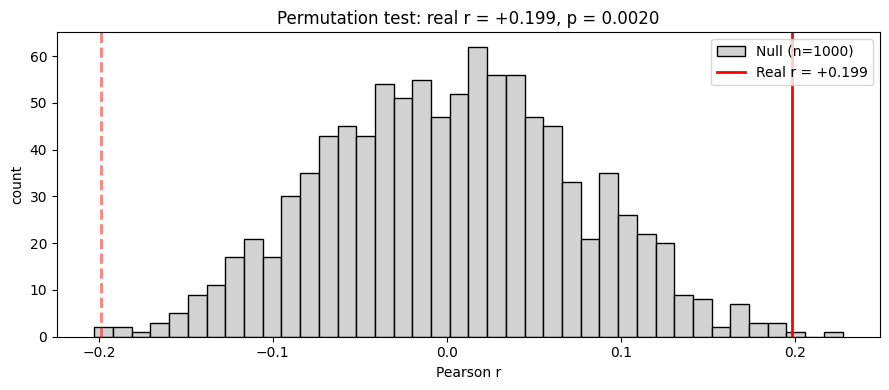

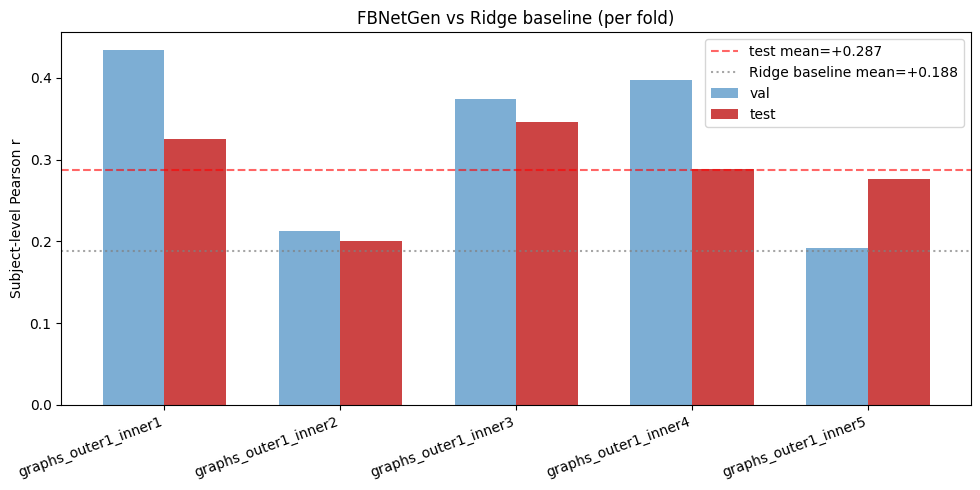

Saved enhanced summary (with permutation + baselines) to: /content/local-scratch/picseq_fbnetgen_h100_optuna_latest/final_best_config_advanced_v2/fbnetgen_final_summary.json


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

# 1. PERMUTATION TEST on pooled subject-level test predictions
preds_pooled  = pooled_test_subject_df['pred'].to_numpy()
targets_pooled = pooled_test_subject_df['target'].to_numpy()

n_perm = 1000
rng = np.random.RandomState(BASE_SEED)

real_r, _ = pearsonr(preds_pooled, targets_pooled)
null_rs = np.empty(n_perm, dtype=float)
for i in range(n_perm):
    shuffled = rng.permutation(targets_pooled)
    null_rs[i] = pearsonr(preds_pooled, shuffled)[0]

p_two_tailed = float(np.mean(np.abs(null_rs) >= np.abs(real_r)))
p_one_tailed = float(np.mean(null_rs >= real_r))

print('=' * 70)
print('Permutation test (pooled subject-level test predictions)')
print('=' * 70)
print(f'  Real Pearson r    : {real_r:+.4f}')
print(f'  Null mean +/- std : {null_rs.mean():+.4f} +/- {null_rs.std():.4f}')
print(f'  p (two-tailed)    : {p_two_tailed:.4f}')
print(f'  p (one-tailed >= ): {p_one_tailed:.4f}')
print(f'  Significant at 0.05? {"YES" if p_two_tailed < 0.05 else "no"}')

# 2. NULL DISTRIBUTION HISTOGRAM
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(null_rs, bins=40, color='lightgray', edgecolor='black', label=f'Null (n={n_perm})')
ax.axvline(real_r, color='red', linewidth=2, label=f'Real r = {real_r:+.3f}')
ax.axvline(-real_r, color='red', linewidth=2, linestyle='--', alpha=0.5)
ax.set_xlabel('Pearson r'); ax.set_ylabel('count')
ax.set_title(f'Permutation test: real r = {real_r:+.3f}, p = {p_two_tailed:.4f}')
ax.legend()
plt.tight_layout()
plt.savefig(final_dir / 'permutation_test.png', dpi=150)
plt.show()
plt.close()

# 3. PER-FOLD BAR PLOT
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(final_df))
width = 0.35
ax.bar(x - width/2, final_df['val_subj_pearson_r'],  width, label='val',  color='#7daed4')
ax.bar(x + width/2, final_df['test_subj_pearson_r'], width, label='test', color='#cc4444')
ax.axhline(0, color='black', linewidth=0.5)
mean_test = final_df['test_subj_pearson_r'].mean()
ax.axhline(mean_test, color='red', linestyle='--', alpha=0.6,
           label=f'test mean={mean_test:+.3f}')
# Add Ridge baseline as horizontal line for comparison
try:
    ridge_mean = baseline_df['ridge_test_pearson_r'].mean()
    ax.axhline(ridge_mean, color='gray', linestyle=':', alpha=0.7,
               label=f'Ridge baseline mean={ridge_mean:+.3f}')
except Exception:
    pass
ax.set_xticks(x); ax.set_xticklabels(final_df['fold'].tolist(), rotation=20, ha='right')
ax.set_ylabel('Subject-level Pearson r')
ax.set_title('FBNetGen vs Ridge baseline (per fold)')
ax.legend(loc='best')
plt.tight_layout()
plt.savefig(final_dir / 'per_fold_breakdown.png', dpi=150)
plt.show()
plt.close()

# 4. SAVE ENHANCED SUMMARY (with permutation + baseline rows)
enhanced_summary = dict(summary)
enhanced_summary['permutation_test'] = {
    'real_r':         float(real_r),
    'null_mean':      float(null_rs.mean()),
    'null_std':       float(null_rs.std()),
    'p_two_tailed':   p_two_tailed,
    'p_one_tailed':   p_one_tailed,
    'n_permutations': n_perm,
}
try:
    enhanced_summary['baselines'] = {
        'ridge_test_pearson_r_mean': float(baseline_df['ridge_test_pearson_r'].mean()),
        'ridge_test_pearson_r_std':  float(baseline_df['ridge_test_pearson_r'].std()),
        'ridge_test_mse_mean':       float(baseline_df['ridge_test_mse'].mean()),
        'fbnetgen_minus_ridge_mean': float(final_df['test_subj_pearson_r'].mean()
                                            - baseline_df['ridge_test_pearson_r'].mean()),
    }
except Exception:
    pass
with open(final_dir / 'fbnetgen_final_summary.json', 'w') as f:
    json.dump(enhanced_summary, f, indent=2)
print(f'Saved enhanced summary (with permutation + baselines) to: {final_dir / "fbnetgen_final_summary.json"}')


## 7.6. Optuna Search Diagnostics (optional)

Visualises trial-by-trial value evolution and parameter importance. Helps understand whether the search converged on a stable optimum or was still wandering when it ran out of trials.

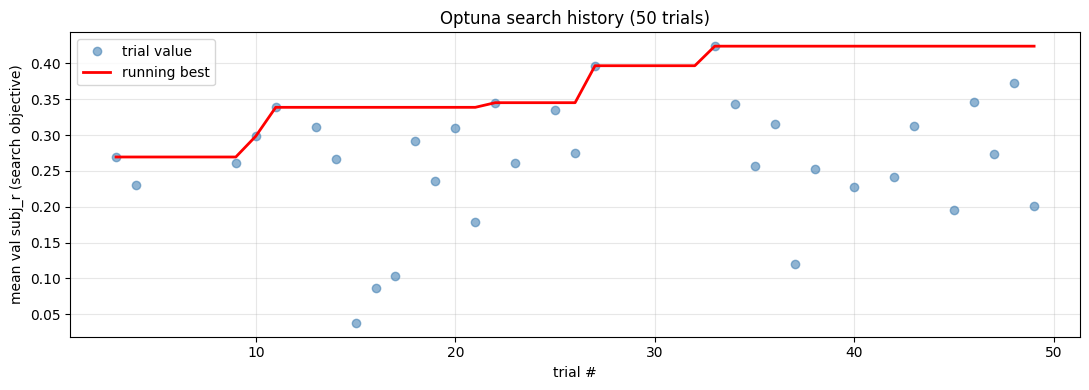

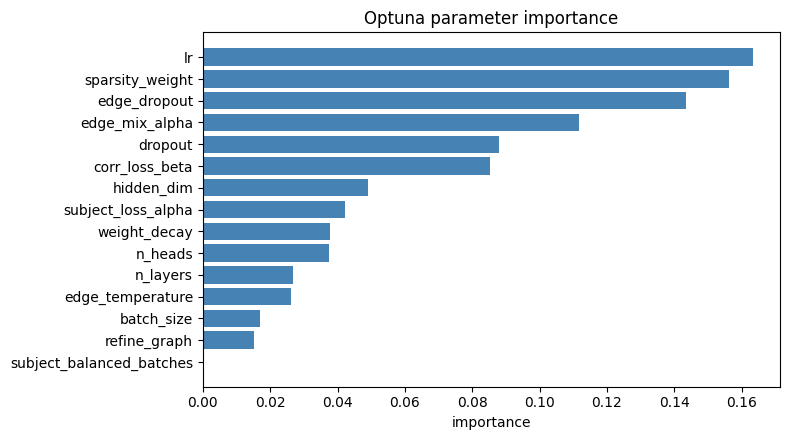

Top 5 most important params: ['lr', 'sparsity_weight', 'edge_dropout', 'edge_mix_alpha', 'dropout']


In [ ]:
import matplotlib.pyplot as plt

# 1. Optuna value history
fig, ax = plt.subplots(figsize=(11, 4))
trial_vals = [t.value if t.value is not None else float('nan') for t in study.trials]
running_best = []
cur_best = -float('inf')
for v in trial_vals:
    if v is not None and not (isinstance(v, float) and np.isnan(v)) and v > cur_best:
        cur_best = v
    running_best.append(cur_best if cur_best > -float('inf') else None)

ax.plot(range(len(trial_vals)), trial_vals, 'o', color='steelblue', alpha=0.6, label='trial value')
ax.plot(range(len(running_best)), running_best, '-', color='red', linewidth=2, label='running best')
ax.set_xlabel('trial #'); ax.set_ylabel('mean val subj_r (search objective)')
ax.set_title(f'Optuna search history ({len(study.trials)} trials)')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(save_dir / 'optuna_history.png', dpi=150)
plt.show()
plt.close()

# 2. Parameter importance (if enough completed trials)
try:
    import optuna
    completed = [t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE]
    if len(completed) >= 10:
        importance = optuna.importance.get_param_importances(study)
        params = list(importance.keys())
        vals = [importance[p] for p in params]
        fig, ax = plt.subplots(figsize=(8, max(4, 0.3 * len(params))))
        ax.barh(params[::-1], vals[::-1], color='steelblue')
        ax.set_xlabel('importance'); ax.set_title('Optuna parameter importance')
        plt.tight_layout()
        plt.savefig(save_dir / 'optuna_param_importance.png', dpi=150)
        plt.show()
        plt.close()
        print(f'Top 5 most important params: {params[:5]}')
    else:
        print(f'Skipping importance plot ({len(completed)} completed trials, need >=10).')
except Exception as e:
    print(f'Could not compute parameter importance: {e}')


## 8. Copy Results Back to Drive

In [ ]:
if USE_SCRATCH_DISK and save_dir != drive_out:
    print(f'Copying {save_dir} -> {drive_out}')
    drive_out.mkdir(parents=True, exist_ok=True)
    output_files = [src for src in sorted(save_dir.rglob('*')) if src.is_file()]
    copy_workers = min(8, max(1, len(output_files)), max(2, (os.cpu_count() or 2) // 2))
    print(f'Copying {len(output_files)} output file(s) with {copy_workers} worker(s)...')

    def copy_output_file(src):
        rel = src.relative_to(save_dir)
        dst = drive_out / rel
        dst.parent.mkdir(parents=True, exist_ok=True)
        shutil.copy2(src, dst)
        return rel

    copied = 0
    with ThreadPoolExecutor(max_workers=copy_workers) as ex:
        futures = [ex.submit(copy_output_file, src) for src in output_files]
        for fut in as_completed(futures):
            fut.result()
            copied += 1
    print(f'Copied {copied} files to Drive: {drive_out}')
    print(f'Drive Optuna Excel: {drive_out / "optuna_search_report.xlsx"}')
    print(f'Drive final Excel : {drive_out / "final_best_config_advanced_v2" / "fbnetgen_final_performance_advanced_v2.xlsx"}')
else:
    print(f'Results already saved in Drive: {drive_out}')
    print(f'Drive Optuna Excel: {drive_out / "optuna_search_report.xlsx"}')
    print(f'Drive final Excel : {drive_out / "final_best_config_advanced_v2" / "fbnetgen_final_performance_advanced_v2.xlsx"}')

Copying /content/local-scratch/picseq_fbnetgen_h100_optuna_latest -> /content/drive/MyDrive/results/picseq_fbnetgen_h100_optuna_latest
Copying 132 output file(s) with 8 worker(s)...
Copied 132 files to Drive: /content/drive/MyDrive/results/picseq_fbnetgen_h100_optuna_latest
Drive Optuna Excel: /content/drive/MyDrive/results/picseq_fbnetgen_h100_optuna_latest/optuna_search_report.xlsx
Drive final Excel : /content/drive/MyDrive/results/picseq_fbnetgen_h100_optuna_latest/final_best_config_advanced_v2/fbnetgen_final_performance_advanced_v2.xlsx


## Practical H100 Notes

- Keep `OPTUNA_N_JOBS = 1` on a single H100. Multiple trials on one GPU usually reduce throughput and can cause OOM.
- Increase `N_TRIALS` to `100` after the first 50-trial run if the best values are still improving.
- Set `OPTUNA_FOLD_LIMIT = None` for the most reliable search, but it will take much longer.
- If OOM happens often, remove `512` from the `batch_size` search list.
- If validation `r` is noisy, prefer more folds in the search over more epochs per trial.